In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize, OneHotEncoder

In [ ]:
!pip -q install optuna joblib

import json
import numpy as np
import pandas as pd
import joblib
import optuna
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 131.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.4/611.4 kB 56.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATA_PATH = "/content/drive/Shareddrives/VR study shared drive/TAMU Raw Data - Labelled/Processed Data_ML/OSU/combined_features_OSU_additional features.csv"

print("File exists:", os.path.exists(DATA_PATH))

File exists: True


In [ ]:
DATA_PATH = "/content/drive/Shareddrives/VR study shared drive/TAMU Raw Data - Labelled/Processed Data_ML/OSU/combined_features_OSU_additional features.csv"
df = pd.read_csv(DATA_PATH)

NUMERIC_FEATURES = [
    "ibi mean", "ibi stdev", "bvp amplitude", "pcps", "blink rate",
    "error rate"
]

CATEGORICAL_FEATURES = ["Type", "Cue"]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "rating"

# Auto-detect participant/group column
POSSIBLE_GROUP_COLS = [
    "Participant ID", "participant_id", "ParticipantID", "participant",
    "Subject", "subject", "subj", "Subject ID", "subject_id"
]
group_col = next((c for c in POSSIBLE_GROUP_COLS if c in df.columns), None)
if group_col is None:
    raise ValueError(
        f"Could not find Participant ID column.\n"
        f"Available columns: {list(df.columns)}\n"
        f"Rename your participant column to one of: {POSSIBLE_GROUP_COLS}"
    )

missing_cols = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

X = df[FEATURES].copy()

y_raw = df[TARGET].copy()
groups = df[group_col].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw.astype(str))
class_names = list(le.classes_)
n_classes = len(class_names)

print("Rows:", len(df))
print("Features:", FEATURES)
print("Target:", TARGET, "| Classes:", class_names)
print("Group column:", group_col, "| Unique participants:", groups.nunique())

Rows: 9853
Features: ['ibi mean', 'ibi stdev', 'bvp amplitude', 'pcps', 'blink rate', 'error rate', 'Type', 'Cue']
Target: rating | Classes: ['High', 'Low', 'Medium']
Group column: Participant ID | Unique participants: 36


In [ ]:
gss = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train+CV participants:", groups_train.nunique())
print("Test participants:", groups_test.nunique())

Train+CV participants: 28
Test participants: 8


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

def build_pipeline(params):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, NUMERIC_FEATURES),
            ("cat", categorical_transformer, CATEGORICAL_FEATURES),
        ]
    )

    clf = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        bootstrap=params["bootstrap"],
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", clf)
    ])

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

def compute_fold_metrics(y_true, y_proba, y_pred, classes_):
    """
    LOSO-safe metrics:
    - Works when validation fold has 1 class, 2 classes (binary), or 3+ classes (multiclass)
    - Aligns proba columns using classes_
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    m = {}
    m["accuracy"] = float(accuracy_score(y_true, y_pred))

    m["f1_macro"] = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    m["precision_macro"] = float(precision_score(y_true, y_pred, average="macro", zero_division=0))
    m["recall_macro"] = float(recall_score(y_true, y_pred, average="macro", zero_division=0))

    m["f1_weighted"] = float(f1_score(y_true, y_pred, average="weighted", zero_division=0))
    m["precision_weighted"] = float(precision_score(y_true, y_pred, average="weighted", zero_division=0))
    m["recall_weighted"] = float(recall_score(y_true, y_pred, average="weighted", zero_division=0))

    # ---------- ROC-AUC (safe) ----------
    present = np.unique(y_true)

    # AUC undefined if only one class is present
    if len(present) < 2:
        m["roc_auc"] = np.nan
        return m

    # Map class label -> proba column index
    class_to_col = {c: i for i, c in enumerate(classes_)}

    # ---------- Binary case ----------
    if len(present) == 2:
        # pick a "positive" class deterministically
        pos_class = present[1]  # higher label; consistent choice

        # if the positive class isn't in classes_ for some reason, bail safely
        if pos_class not in class_to_col:
            m["roc_auc"] = np.nan
            return m

        pos_col = class_to_col[pos_class]
        y_score = y_proba[:, pos_col]          # <- 1D (n,) REQUIRED for binary AUC
        y_bin = (y_true == pos_class).astype(int)

        m["roc_auc"] = float(roc_auc_score(y_bin, y_score))
        return m

    # ---------- Multiclass case (3+ classes) ----------
    cols = [class_to_col[c] for c in present if c in class_to_col]
    if len(cols) < 2:
        m["roc_auc"] = np.nan
        return m

    m["roc_auc"] = float(
        roc_auc_score(
            y_true,
            y_proba[:, cols],
            labels=present,
            multi_class="ovr",
            average="macro",
        )
    )
    return m

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
import numpy as np

logo = LeaveOneGroupOut()

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 60),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
    }

    pipe = build_pipeline(params)

    fold_f1 = []
    fold_auc = []

    for tr_i, va_i in logo.split(X_train, y_train, groups=groups_train):
        X_tr, X_va = X_train.iloc[tr_i], X_train.iloc[va_i]
        y_tr, y_va = y_train[tr_i], y_train[va_i]

        pipe.fit(X_tr, y_tr)

        y_proba = pipe.predict_proba(X_va)
        y_pred = np.argmax(y_proba, axis=1)

        # IMPORTANT: class order for predict_proba columns
        if hasattr(pipe, "classes_"):
            classes_ = pipe.classes_
        else:
            # change "clf" to your estimator step name if needed
            classes_ = pipe.named_steps["clf"].classes_

        m = compute_fold_metrics(y_va, y_proba, y_pred, classes_=classes_)
        fold_f1.append(m["f1_macro"])
        fold_auc.append(m["roc_auc"])  # may be nan for 1-class folds

    trial.set_user_attr("mean_auc", float(np.nanmean(fold_auc)))
    return float(np.mean(fold_f1))

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-05-14 23:08:07,548] A new study created in memory with name: no-name-867ca57b-fbf0-4e7f-a354-12ee8677fe3d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-14 23:08:56,887] Trial 0 finished with value: 0.41382814111647664 and parameters: {'n_estimators': 689, 'max_depth': 41, 'min_samples_split': 30, 'min_samples_leaf': 22, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.41382814111647664.
[I 2026-05-14 23:09:16,965] Trial 1 finished with value: 0.3933066429326945 and parameters: {'n_estimators': 256, 'max_depth': 50, 'min_samples_split': 25, 'min_samples_leaf': 30, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.41382814111647664.
[I 2026-05-14 23:09:59,912] Trial 2 finished with value: 0.4112762840196495 and parameters: {'n_estimators': 603, 'max_depth': 60, 'min_samples_split': 33, 'min_samples_leaf': 23, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.41382814111647664.
[I 2026-05-14 23:11:56,660] Trial 3 finished with value: 0.41360659755467716 and parameters: {'n_estimators': 1649, 'max_depth': 25, 'min_samples_split': 23, 'min_samples_leaf': 6, '

In [ ]:
best_params = study.best_params
print("Best params:", best_params)

Best params: {'n_estimators': 1563, 'max_depth': 30, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': True}


===== TEST METRICS =====
Accuracy: 0.8082
F1 (macro): 0.5273 | F1 (weighted): 0.7805
Precision (macro): 0.5117 | Precision (weighted): 0.7683
Recall (macro): 0.5995 | Recall (weighted): 0.8082
ROC-AUC (macro): 0.8570 | ROC-AUC (weighted): 0.8497


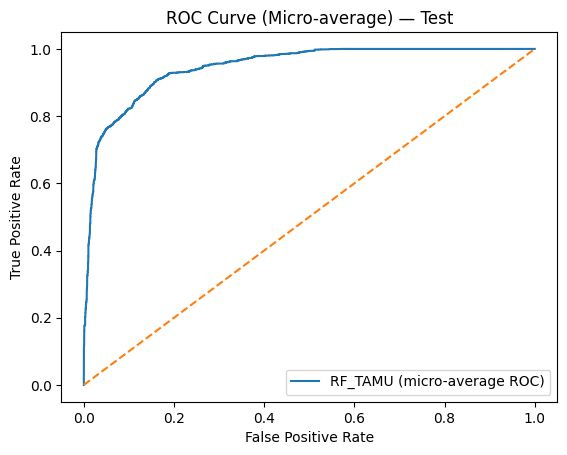

Saved:
 - test_predictions_for_roc_comparison_RF_TAMU.npz
 - roc_artifact_RF_TAMU.json


In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize


def safe_test_auc(y_true, y_proba, classes_):
    """
    Safe ROC-AUC on the TEST set.
    Handles:
      - binary: uses 1D scores for positive class
      - multiclass: evaluates only on classes present in y_true
      - if only 1 class present -> returns (nan, nan)
    Returns: (auc_macro, auc_weighted)
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    classes_ = np.asarray(classes_)

    present = np.unique(y_true)

    # AUC undefined if only one class appears in y_true
    if len(present) < 2:
        return np.nan, np.nan

    class_to_col = {c: i for i, c in enumerate(classes_)}

    # Binary case (test has exactly 2 classes)
    if len(present) == 2:
        # choose positive class deterministically
        pos_class = present[1]
        if pos_class not in class_to_col:
            return np.nan, np.nan
        pos_col = class_to_col[pos_class]

        y_score = y_proba[:, pos_col]                 # 1D required
        y_bin = (y_true == pos_class).astype(int)

        auc = roc_auc_score(y_bin, y_score)
        return float(auc), float(auc)

    # Multiclass case (3+ classes present in test)
    cols = [class_to_col[c] for c in present if c in class_to_col]
    if len(cols) < 2:
        return np.nan, np.nan

    auc_macro = roc_auc_score(
        y_true,
        y_proba[:, cols],
        labels=present,
        multi_class="ovr",
        average="macro",
    )
    auc_weighted = roc_auc_score(
        y_true,
        y_proba[:, cols],
        labels=present,
        multi_class="ovr",
        average="weighted",
    )
    return float(auc_macro), float(auc_weighted)


def plot_and_store_roc(y_true, y_proba, classes_, model_name):
    """
    Creates ROC plot and returns curves dict for artifact.
    - binary: standard ROC
    - multiclass: micro-average ROC using label_binarize with classes_
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    classes_ = np.asarray(classes_)

    present = np.unique(y_true)

    curves = {}

    plt.figure()

    # If only one class present, ROC curve is undefined
    if len(present) < 2:
        plt.title("ROC Curve — Undefined (only 1 class in y_true)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.show()
        return curves

    class_to_col = {c: i for i, c in enumerate(classes_)}

    # Binary ROC (test has exactly 2 classes)
    if len(present) == 2:
        pos_class = present[1]
        pos_col = class_to_col[pos_class]

        y_score = y_proba[:, pos_col]
        y_bin = (y_true == pos_class).astype(int)

        fpr, tpr, _ = roc_curve(y_bin, y_score)
        plt.plot(fpr, tpr, label=f"{model_name} (binary ROC)")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve (Binary) — Test")
        plt.legend(loc="lower right")

        curves["binary"] = {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "pos_class": str(pos_class)}
        plt.show()
        return curves

    # Multiclass micro-average ROC
    # Use full classes_ so binarize has consistent columns
    y_true_bin = label_binarize(y_true, classes=classes_)

    # If some classes in classes_ are absent in y_true, corresponding columns are all-zeros—OK.
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())

    plt.plot(fpr_micro, tpr_micro, label=f"{model_name} (micro-average ROC)")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Micro-average) — Test")
    plt.legend(loc="lower right")

    curves["micro"] = {"fpr": fpr_micro.tolist(), "tpr": tpr_micro.tolist()}
    plt.show()
    return curves


# =========================
# FINAL TRAIN + TEST EVAL
# =========================

MODEL_NAME = "RF_TAMU"

final_model = build_pipeline(best_params)
final_model.fit(X_train, y_train)

test_proba = final_model.predict_proba(X_test)
#test_pred = np.argmax(test_proba, axis=1)
test_pred = final_model.predict(X_test)


# IMPORTANT: class order that matches predict_proba columns
if hasattr(final_model, "classes_"):
    classes_ = final_model.classes_
else:
    # change "clf" to your estimator step name if needed
    classes_ = final_model.named_steps["clf"].classes_

n_classes_model = len(classes_)

# --- standard metrics ---
acc = accuracy_score(y_test, test_pred)

f1_macro = f1_score(y_test, test_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_test, test_pred, average="weighted", zero_division=0)

prec_macro = precision_score(y_test, test_pred, average="macro", zero_division=0)
prec_weighted = precision_score(y_test, test_pred, average="weighted", zero_division=0)

rec_macro = recall_score(y_test, test_pred, average="macro", zero_division=0)
rec_weighted = recall_score(y_test, test_pred, average="weighted", zero_division=0)

# --- safe ROC-AUC ---
roc_auc_macro, roc_auc_weighted = safe_test_auc(y_test, test_proba, classes_)

print("===== TEST METRICS =====")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (macro): {f1_macro:.4f} | F1 (weighted): {f1_weighted:.4f}")
print(f"Precision (macro): {prec_macro:.4f} | Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (macro): {rec_macro:.4f} | Recall (weighted): {rec_weighted:.4f}")
print(f"ROC-AUC (macro): {roc_auc_macro:.4f} | ROC-AUC (weighted): {roc_auc_weighted:.4f}")

# --- ROC plot + curves dict for artifact ---
curves = plot_and_store_roc(y_test, test_proba, classes_, MODEL_NAME)

# --- artifact metadata ---
roc_artifact = {
    "model_name": MODEL_NAME,
    "class_names": [str(c) for c in classes_],      # aligned to proba columns
    "n_classes_model": int(n_classes_model),
    "roc_auc_macro": float(roc_auc_macro) if np.isfinite(roc_auc_macro) else None,
    "roc_auc_weighted": float(roc_auc_weighted) if np.isfinite(roc_auc_weighted) else None,
    "feature_list": FEATURES,
    "group_column": group_col,
    "test_size_participants_frac": 0.20,
    "random_state": 42,
    "test_indices_hash": str(hash(tuple(np.array(test_idx).tolist()))),
    "curves": curves,
}

# --- save predictions for later overlay ---
np.savez(
    f"test_predictions_for_roc_comparison_{MODEL_NAME}.npz",
    y_true=np.array(y_test),
    y_proba=np.array(test_proba),
    test_indices=np.array(test_idx),
    test_groups=np.array(groups_test),
    class_names=np.array([str(c) for c in classes_], dtype=object),
)

with open(f"roc_artifact_{MODEL_NAME}.json", "w") as f:
    json.dump(roc_artifact, f, indent=2)

print("Saved:")
print(f" - test_predictions_for_roc_comparison_{MODEL_NAME}.npz")
print(f" - roc_artifact_{MODEL_NAME}.json")

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, test_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {c}" for c in class_names],
    columns=[f"Predicted: {c}" for c in class_names]
)

print("\n===== CONFUSION MATRIX =====")
print(cm_df)


===== CONFUSION MATRIX =====
                Predicted: High  Predicted: Low  Predicted: Medium
Actual: High                 30             273                 37
Actual: Low                 204            2020                180
Actual: Medium               61             345                 42


In [ ]:
joblib.dump(final_model, "rf_model.joblib")
joblib.dump(le, "label_encoder.joblib")

with open("feature_list.json", "w") as f:
    json.dump(FEATURES, f, indent=2)

print("Saved:")
print(" - rf_model.joblib")
print(" - label_encoder.joblib")
print(" - feature_list.json")
print(" - best_hyperparams.json")

Saved:
 - rf_model.joblib
 - label_encoder.joblib
 - feature_list.json
 - best_hyperparams.json


In [ ]:
import os
import shutil

drive_path = "/content/drive/Shareddrives/VR study shared drive/TAMU Raw Data - Labelled/Processed Data_ML/TAMU/Models/RF"

# Create folder if it doesn't exist
os.makedirs(drive_path, exist_ok=True)

files_to_copy = [
    "rf_model.joblib",
    "label_encoder.joblib",
    "feature_list.json",
    "best_hyperparams.json",   # <-- fixed filename
    "roc_artifact_RF_TAMU.json",
    "test_predictions_for_roc_comparison_RF_TAMU.npz"
]

for f in files_to_copy:
    if os.path.exists(f):
        shutil.copy(f, drive_path)
        print(f"Copied: {f}")
    else:
        print(f"WARNING: File not found -> {f}")

print("All available files copied to Drive:")
print(drive_path)

Copied: rf_model.joblib
Copied: label_encoder.joblib
Copied: feature_list.json
Copied: roc_artifact_RF_TAMU.json
Copied: test_predictions_for_roc_comparison_RF_TAMU.npz
All available files copied to Drive:
/content/drive/Shareddrives/VR study shared drive/TAMU Raw Data - Labelled/Processed Data_ML/TAMU/Models/RF
